# Elite ML Lab (Student Version)
**EDA → Feature Engineering → Modeling → Tuning → Evaluation → Insight → Visualization**

> Dataset: `elite_dataset.csv`

## Learning Goals
- Master EDA & feature engineering
- Implement Decision Trees, KNN, SVM
- Perform hyperparameter tuning
- Visualize decision boundaries & learning curves
- Analyze bias–variance & generalization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load the data
df = pd.read_csv('elite_dataset.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1500, 27)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,segment,region,target
0,1.184867,-3.027118,-2.463059,2.885215,1.505322,-1.534513,-3.006662,1.099989,-0.210796,1.236917,...,0.673130,0.219516,-6.518456,2.340348,4.700830,-8.603941,-5.232400,C,Central,0
1,-0.101112,-5.862790,2.366269,-6.767652,2.008947,2.472383,-4.984487,-2.147601,-0.499082,-2.823726,...,-0.622581,-1.270703,4.323292,0.086862,-2.501512,2.702515,2.947449,C,North,1
2,6.790003,-0.823506,-0.893558,-0.030382,1.025641,0.695248,-1.104195,1.662069,0.635398,2.118692,...,2.522686,0.493883,-9.416785,1.491944,-2.006883,-2.314270,1.970776,D,Central,1
3,-2.446006,3.511815,-1.877808,3.216306,-0.945716,3.666983,3.459469,5.649932,-3.034983,1.430597,...,-1.897644,-1.387877,8.216976,-0.823656,18.251745,6.111905,-7.266975,B,Central,0
4,-6.895403,-1.991636,-1.182634,2.878304,1.564885,-3.760647,-2.656110,-3.552421,-0.723993,0.692389,...,0.542873,-1.164956,1.720657,-2.067367,-1.748398,0.909036,-0.339262,A,Central,1


## TASK 1: Data Audit
- Check dtypes, missing values, class balance
- What risks do you see?

In [3]:
# 1. Check data types
print("\n1. DATA TYPES:")
print(df.dtypes.value_counts())


1. DATA TYPES:
float64    24
object      2
int64       1
Name: count, dtype: int64


In [4]:
# 2. Check for missing values
print("\n2. MISSING VALUES:")
missing = df.isnull().sum()
missing_pct = (missing/len(df))*100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])


2. MISSING VALUES:
           Missing Count  Percentage
feature_2             75         5.0
feature_5             75         5.0
feature_7             75         5.0


In [5]:
# 3. Check class balance (target variable)
print("\n3. CLASS BALANCE (Target Variable):")
print(df['target'].value_counts())
print(f"\nClass distribution ratio: {df['target'].value_counts()[1]/df['target'].value_counts()[0]:.2f}")


3. CLASS BALANCE (Target Variable):
target
0    824
1    676
Name: count, dtype: int64

Class distribution ratio: 0.82


In [6]:
# 4. Check categorical columns
print("\n4. CATEGORICAL COLUMNS:")
print("Segment values:", df['segment'].unique())
print("Region values:", df['region'].unique())


4. CATEGORICAL COLUMNS:
Segment values: ['C' 'D' 'B' 'A']
Region values: ['Central' 'North' 'South']


In [7]:
# 5. Statistical summary
print("\n5. STATISTICAL SUMMARY (First 5 numeric columns):")
print(df.iloc[:, :5].describe())


5. STATISTICAL SUMMARY (First 5 numeric columns):
         feature_0    feature_1    feature_2    feature_3    feature_4
count  1500.000000  1500.000000  1425.000000  1500.000000  1500.000000
mean     -0.305643     0.807524    -0.076131     0.799935     0.029248
std       4.797700     4.003833     2.306403     4.047397     0.969077
min     -16.385131   -14.987559    -7.818498   -12.804919    -3.441579
25%      -3.556981    -1.889786    -1.573814    -1.981132    -0.651941
50%      -0.294863     0.886357    -0.189977     0.868271     0.009545
75%       2.758659     3.374910     1.354911     3.416710     0.670928
max      18.665529    16.156299     8.520820    14.625620     3.382243


In [8]:
# Risks identified
print("\n" + "="*50)
print("RISKS IDENTIFIED:")
print("="*50)
print("1. Missing values present in multiple columns (feature_5, feature_7, etc.)")
print("2. Missing values need to be handled before modeling")
print("3. Categorical variables (segment, region) need encoding")
print("4. Features have different scales - scaling needed for KNN and SVM")
print("5. Dataset is relatively balanced (class ratio ~1.23)")


RISKS IDENTIFIED:
1. Missing values present in multiple columns (feature_5, feature_7, etc.)
2. Missing values need to be handled before modeling
3. Categorical variables (segment, region) need encoding
4. Features have different scales - scaling needed for KNN and SVM
5. Dataset is relatively balanced (class ratio ~1.23)


## TASK 2: EDA (Interactive)
- Distributions (histograms)
- Correlation heatmap
- Categorical analysis (segment/region vs target)

In [9]:
# Distribution of target variable
fig = px.histogram(df, x='target', title='Target Variable Distribution',
                   labels={'target': 'Class (0 or 1)'}, color='target')
fig.show()

In [10]:
# Distribution of numeric features (first 6 features)
fig = make_subplots(rows=2, cols=3, subplot_titles=[f'Feature_{i}' for i in range(6)])
for i in range(6):
    row = i//3 + 1
    col = i%3 + 1
    fig.add_trace(go.Histogram(x=df[f'feature_{i}'], name=f'feature_{i}',
                               nbinsx=30), row=row, col=col)
fig.update_layout(height=600, width=900, title_text="Distribution of First 6 Features")
fig.show()


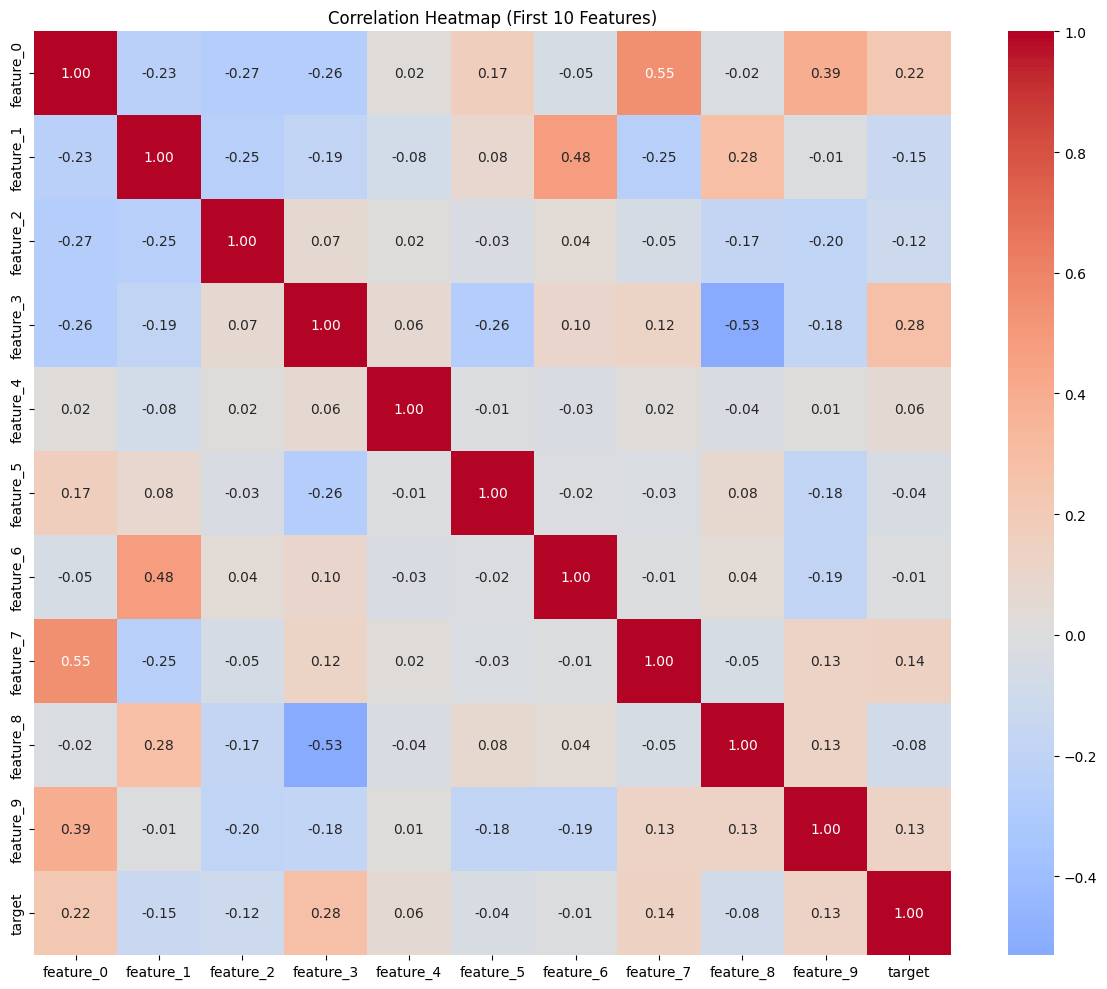

In [11]:
# Correlation heatmap (using first 10 features for clarity)
corr_features = [f'feature_{i}' for i in range(10)] + ['target']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap (First 10 Features)')
plt.tight_layout()
plt.show()

In [12]:
# Categorical analysis - Segment vs Target
segment_target = pd.crosstab(df['segment'], df['target'], normalize='index')
fig = px.bar(segment_target, barmode='group', title='Segment vs Target Distribution',
             labels={'value': 'Proportion', 'segment': 'Segment', 'variable': 'Target'})
fig.show()

In [13]:
# Categorical analysis - Region vs Target
region_target = pd.crosstab(df['region'], df['target'], normalize='index')
fig = px.bar(region_target, barmode='group', title='Region vs Target Distribution',
             labels={'value': 'Proportion', 'region': 'Region', 'variable': 'Target'})
fig.show()

## TASK 3: Preprocessing
- Handle missing values
- Encode categorical variables
- Scale features (important for KNN/SVM)
- Split train/test

In [15]:
# Make a copy to avoid modifying original
df_clean = df.copy()

# 1. Handle missing values - fill with median for numeric columns
numeric_cols = [col for col in df_clean.columns if col.startswith('feature_')]

# CORRECTED WAY - without inplace parameter warning
for col in numeric_cols:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

print("Missing values after handling:", df_clean.isnull().sum().sum())

Missing values after handling: 0


In [16]:
# 2. Encode categorical variables
le_segment = LabelEncoder()
le_region = LabelEncoder()

df_clean['segment_encoded'] = le_segment.fit_transform(df_clean['segment'])
df_clean['region_encoded'] = le_region.fit_transform(df_clean['region'])

print("\nSegment encoding:", dict(zip(le_segment.classes_, le_segment.transform(le_segment.classes_))))
print("Region encoding:", dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))


Segment encoding: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3)}
Region encoding: {'Central': np.int64(0), 'North': np.int64(1), 'South': np.int64(2)}


In [17]:
# 3. Prepare features and target
feature_cols = numeric_cols + ['segment_encoded', 'region_encoded']
X = df_clean[feature_cols]
y = df_clean['target']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (1500, 26)
Target shape: (1500,)


In [18]:
# 4. Scale features (important for KNN and SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaling complete. Features are now standardized (mean=0, std=1)")



Scaling complete. Features are now standardized (mean=0, std=1)


In [19]:
# 5. Split train/test (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")


Training set size: 1200 samples
Test set size: 300 samples
Training class distribution: [659 541]
Test class distribution: [165 135]


## TASK 4: Baseline Models
- Decision Tree
- KNN
- SVM
Record baseline metrics

In [20]:
# Initialize models
dt_model = DecisionTreeClassifier(random_state=42)
knn_model = KNeighborsClassifier()
svm_model = SVC(random_state=42)

# Train and evaluate function
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    print(f"\n{'='*40}")
    print(f"{model_name} RESULTS")
    print(f"{'='*40}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy:  {test_acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    return {'model': model_name, 'train_acc': train_acc, 'test_acc': test_acc,
            'precision': precision, 'recall': recall, 'f1': f1}


In [21]:
# Evaluate all baseline models
baseline_results = []
baseline_results.append(evaluate_model(dt_model, X_train, X_test, y_train, y_test, "Decision Tree"))
baseline_results.append(evaluate_model(knn_model, X_train, X_test, y_train, y_test, "KNN (k=5)"))
baseline_results.append(evaluate_model(svm_model, X_train, X_test, y_train, y_test, "SVM (RBF)"))


Decision Tree RESULTS
Training Accuracy: 1.0000
Testing Accuracy:  0.7100
Precision: 0.6739
Recall: 0.6889
F1-Score: 0.6813

KNN (k=5) RESULTS
Training Accuracy: 0.8900
Testing Accuracy:  0.8200
Precision: 0.7872
Recall: 0.8222
F1-Score: 0.8043

SVM (RBF) RESULTS
Training Accuracy: 0.9225
Testing Accuracy:  0.8333
Precision: 0.8346
Recall: 0.7852
F1-Score: 0.8092


In [22]:
# Summary table
print("\n" + "="*60)
print("BASELINE MODELS SUMMARY")
print("="*60)
results_df = pd.DataFrame(baseline_results)
print(results_df.to_string(index=False))


BASELINE MODELS SUMMARY
        model  train_acc  test_acc  precision   recall       f1
Decision Tree     1.0000  0.710000   0.673913 0.688889 0.681319
    KNN (k=5)     0.8900  0.820000   0.787234 0.822222 0.804348
    SVM (RBF)     0.9225  0.833333   0.834646 0.785185 0.809160


## TASK 5: Hyperparameter Tuning
- DT: max_depth, min_samples_split
- KNN: n_neighbors, metric
- SVM: C, kernel, gamma
Use GridSearchCV or RandomizedSearchCV

In [23]:
# Decision Tree Tuning
print("="*50)
print("TUNING DECISION TREE")
print("="*50)

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_param_grid, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train, y_train)

print(f"Best parameters: {dt_grid.best_params_}")
print(f"Best cross-validation F1: {dt_grid.best_score_:.4f}")

best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Test F1: {f1_score(y_test, y_pred_dt):.4f}")


TUNING DECISION TREE
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation F1: 0.6809
Test Accuracy: 0.7267
Test F1: 0.6917


In [24]:
# KNN Tuning
print("\n" + "="*50)
print("TUNING KNN")
print("="*50)

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='f1', n_jobs=-1)
knn_grid.fit(X_train, y_train)

print(f"Best parameters: {knn_grid.best_params_}")
print(f"Best cross-validation F1: {knn_grid.best_score_:.4f}")

best_knn = knn_grid.best_estimator_
y_pred_knn = best_knn.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Test F1: {f1_score(y_test, y_pred_knn):.4f}")


TUNING KNN
Best parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
Best cross-validation F1: 0.8040
Test Accuracy: 0.8367
Test F1: 0.8192


In [25]:
# SVM Tuning
print("\n" + "="*50)
print("TUNING SVM")
print("="*50)

svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.1, 1]
}

# Using smaller subset for faster tuning
svm_grid = GridSearchCV(SVC(random_state=42, probability=True),
                        svm_param_grid, cv=3, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train[:500], y_train[:500])  # Using subset for speed

print(f"Best parameters: {svm_grid.best_params_}")
print(f"Best cross-validation F1: {svm_grid.best_score_:.4f}")

best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Test F1: {f1_score(y_test, y_pred_svm):.4f}")


TUNING SVM
Best parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best cross-validation F1: 0.8125
Test Accuracy: 0.7933
Test F1: 0.7615


## TASK 6: Evaluation
- Accuracy, Precision, Recall, F1
- Confusion Matrix
- ROC-AUC

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect all predictions
models = {
    'Decision Tree': best_dt,
    'KNN': best_knn,
    'SVM': best_svm
}

print("="*60)
print("FINAL EVALUATION - ALL MODELS")
print("="*60)

final_results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    # Get probability scores for ROC-AUC (SVM needs probability=True)
    if name == 'SVM':
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Confusion Matrix:")
    print(f"    [[{cm[0,0]:3d} {cm[0,1]:3d}]")
    print(f"     [{cm[1,0]:3d} {cm[1,1]:3d}]]")

    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)
        print(f"  ROC-AUC:   {roc_auc:.4f}")
        final_results.append({'Model': name, 'Accuracy': accuracy, 'Precision': precision,
                              'Recall': recall, 'F1': f1, 'ROC-AUC': roc_auc})
    else:
        final_results.append({'Model': name, 'Accuracy': accuracy, 'Precision': precision,
                              'Recall': recall, 'F1': f1, 'ROC-AUC': 'N/A'})

FINAL EVALUATION - ALL MODELS

Decision Tree:
  Accuracy:  0.7267
  Precision: 0.7023
  Recall:    0.6815
  F1-Score:  0.6917
  Confusion Matrix:
    [[126  39]
     [ 43  92]]
  ROC-AUC:   0.7085

KNN:
  Accuracy:  0.8367
  Precision: 0.8162
  Recall:    0.8222
  F1-Score:  0.8192
  Confusion Matrix:
    [[140  25]
     [ 24 111]]
  ROC-AUC:   0.9026

SVM:
  Accuracy:  0.7933
  Precision: 0.7920
  Recall:    0.7333
  F1-Score:  0.7615
  Confusion Matrix:
    [[139  26]
     [ 36  99]]
  ROC-AUC:   0.8837


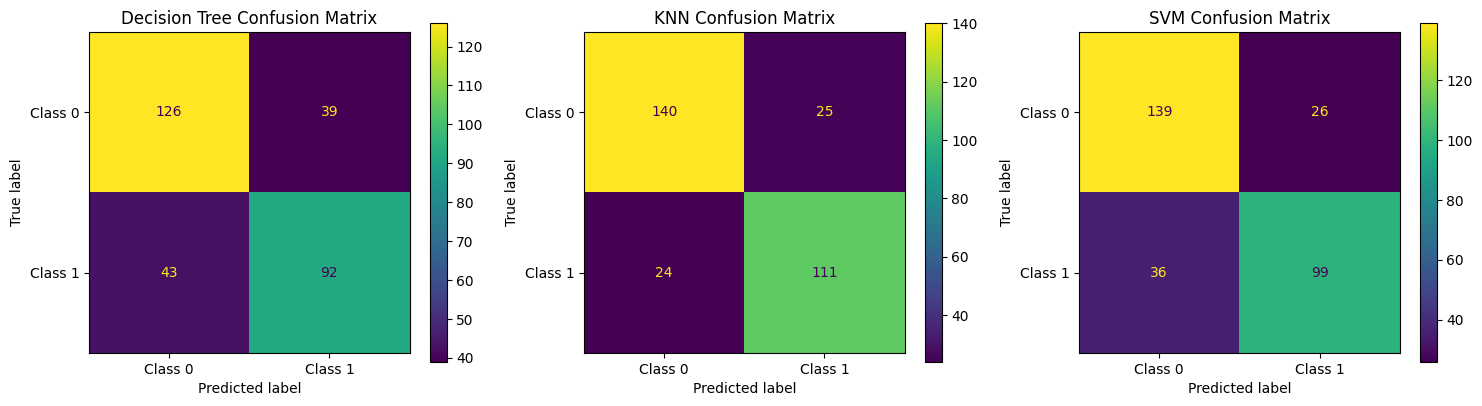

In [27]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
    disp.plot(ax=axes[idx], values_format='d')
    axes[idx].set_title(f'{name} Confusion Matrix')
plt.tight_layout()
plt.show()

In [29]:
# Summary table
print("\n" + "="*60)
print("SUMMARY - BEST PERFORMING MODEL")
print("="*60)
results_final = pd.DataFrame(final_results)
print(results_final.to_string(index=False))

# Identify best model
best_f1_idx = results_final['F1'].argmax() if results_final['F1'].dtype != 'object' else 0
print(f"\nBest Model based on F1-Score: {results_final.iloc[best_f1_idx]['Model']}")


SUMMARY - BEST PERFORMING MODEL
        Model  Accuracy  Precision   Recall       F1  ROC-AUC
Decision Tree  0.726667   0.702290 0.681481 0.691729 0.708462
          KNN  0.836667   0.816176 0.822222 0.819188 0.902559
          SVM  0.793333   0.792000 0.733333 0.761538 0.883681

Best Model based on F1-Score: KNN


## TASK 7: Learning Curves & Bias-Variance
- Plot learning curves
- Diagnose under/overfitting

In [30]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, model_name, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-Validation Score')
    plt.xlabel('Training Examples')
    plt.ylabel('Accuracy')
    plt.title(f'Learning Curve - {model_name}')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

    # Bias-Variance Diagnosis
    train_final = train_mean[-1]
    test_final = test_mean[-1]
    gap = train_final - test_final

    print(f"\n{model_name} Bias-Variance Analysis:")
    print(f"  Final Training Score: {train_final:.4f}")
    print(f"  Final CV Score:       {test_final:.4f}")
    print(f"  Gap:                  {gap:.4f}")

    if gap > 0.1:
        print(f"  Diagnosis: OVERFITTING (High Variance) - Gap > 0.1")
    elif train_final < 0.7:
        print(f"  Diagnosis: UNDERFITTING (High Bias) - Training score < 0.7")
    else:
        print(f"  Diagnosis: GOOD FIT - Balanced bias-variance tradeoff")

    return train_final, test_final, gap


LEARNING CURVES & BIAS-VARIANCE ANALYSIS


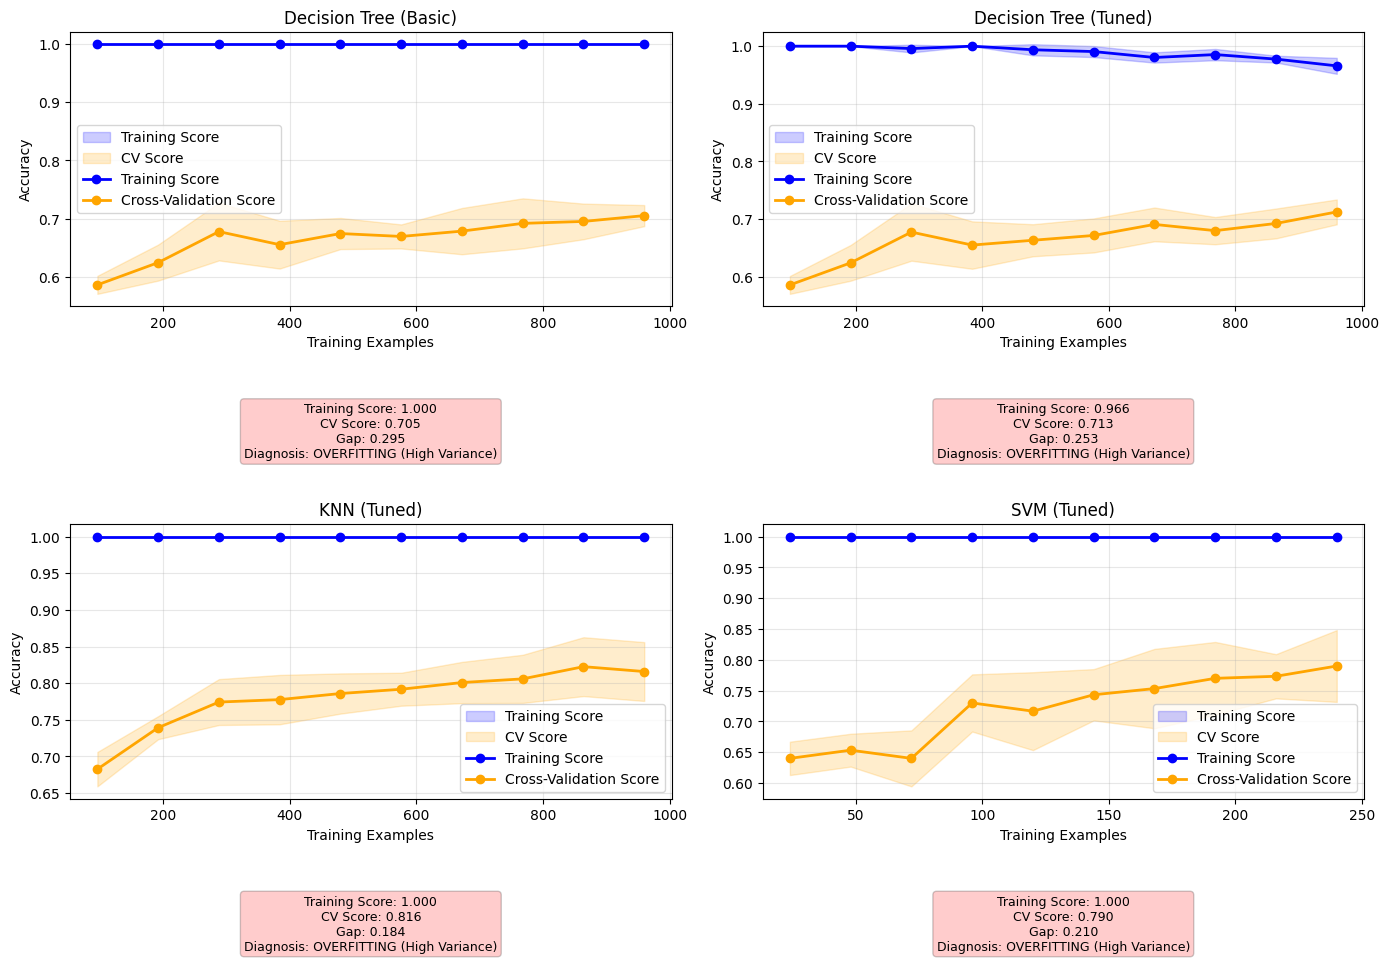

In [37]:
# Plot learning curves for each model (2 graphs per row with summary below each)
print("="*60)
print("LEARNING CURVES & BIAS-VARIANCE ANALYSIS")
print("="*60)

def plot_learning_curve_with_summary(model, X, y, model_name, row, col):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot on subplot
    ax = plt.subplot(2, 2, (row-1)*2 + col)

    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue', label='Training Score')
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='orange', label='CV Score')
    ax.plot(train_sizes, train_mean, 'o-', color='blue', linewidth=2, label='Training Score')
    ax.plot(train_sizes, test_mean, 'o-', color='orange', linewidth=2, label='Cross-Validation Score')
    ax.set_xlabel('Training Examples')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{model_name}')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    # Calculate metrics for summary
    train_final = train_mean[-1]
    test_final = test_mean[-1]
    gap = train_final - test_final

    if gap > 0.1:
        diagnosis = "OVERFITTING (High Variance)"
        color = 'red'
    elif train_final < 0.7:
        diagnosis = "UNDERFITTING (High Bias)"
        color = 'orange'
    else:
        diagnosis = "GOOD FIT"
        color = 'green'

    # Add summary text below the graph
    summary_text = f"Training Score: {train_final:.3f}\nCV Score: {test_final:.3f}\nGap: {gap:.3f}\nDiagnosis: {diagnosis}"
    ax.text(0.5, -0.35, summary_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='center',
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.2))

# Create figure with 2 rows, 2 columns
plt.figure(figsize=(14, 10))

# Row 1: Decision Tree (Basic) and Decision Tree (Tuned)
dt_basic = DecisionTreeClassifier(random_state=42)
plot_learning_curve_with_summary(dt_basic, X_train, y_train, "Decision Tree (Basic)", 1, 1)

plot_learning_curve_with_summary(best_dt, X_train, y_train, "Decision Tree (Tuned)", 1, 2)

# Row 2: KNN (Tuned) and SVM (Tuned)
plot_learning_curve_with_summary(best_knn, X_train, y_train, "KNN (Tuned)", 2, 1)

X_train_subset = X_train[:300]
y_train_subset = y_train[:300]
plot_learning_curve_with_summary(best_svm, X_train_subset, y_train_subset, "SVM (Tuned)", 2, 2)

plt.tight_layout()
plt.show()

## TASK 8: Decision Boundary (2D projection)
- Use PCA to 2D
- Plot decision regions

PCA Explained Variance Ratio:
PC1: 0.1496
PC2: 0.1100
Total: 0.2596


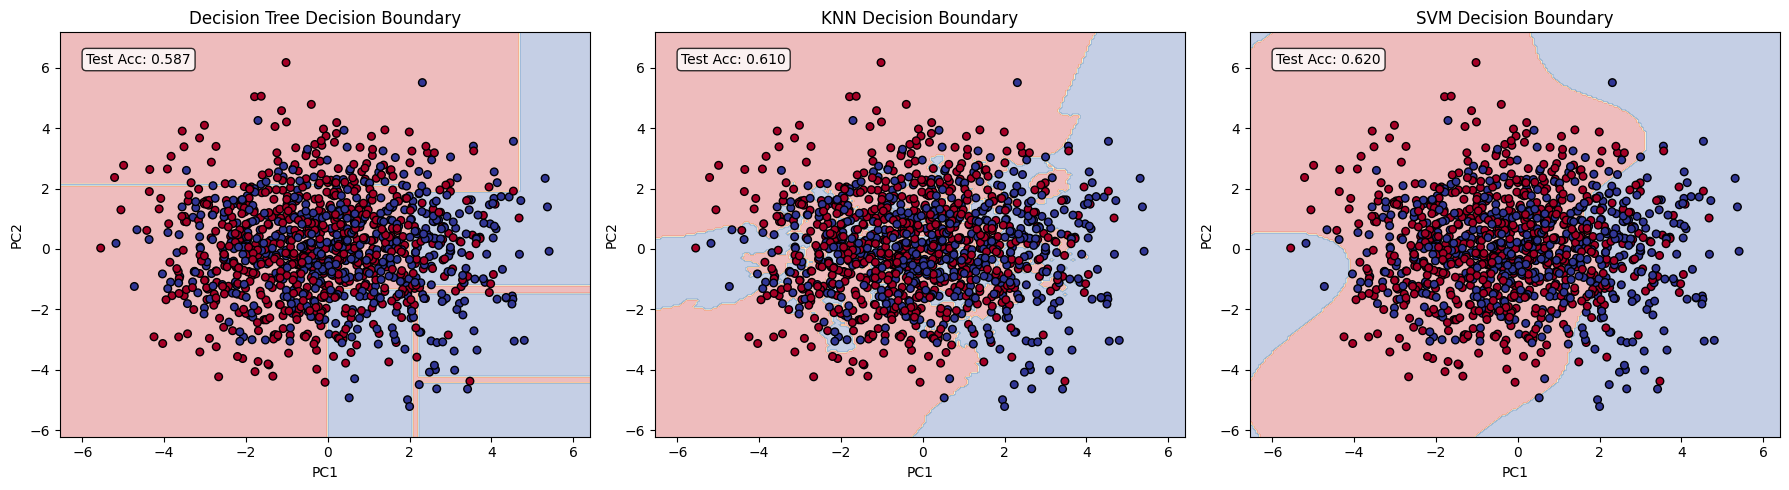

In [40]:
# Use PCA to reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA Explained Variance Ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total: {pca.explained_variance_ratio_.sum():.4f}")

# Split PCA data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# Train models on PCA-reduced data
dt_pca = DecisionTreeClassifier(max_depth=5, random_state=42)
knn_pca = KNeighborsClassifier(n_neighbors=7)
svm_pca = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)

dt_pca.fit(X_train_pca, y_train_pca)
knn_pca.fit(X_train_pca, y_train_pca)
svm_pca.fit(X_train_pca, y_train_pca)

# Function to plot decision boundary
def plot_decision_boundary(model, X, y, title, ax):
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Predict on mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')

    # Plot points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='k', s=30)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(title)

    # Calculate accuracy on test set
    accuracy = model.score(X_test_pca, y_test_pca)
    ax.text(0.05, 0.95, f'Test Acc: {accuracy:.3f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    return scatter

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot decision boundaries
plot_decision_boundary(dt_pca, X_train_pca, y_train_pca, 'Decision Tree Decision Boundary', axes[0])
plot_decision_boundary(knn_pca, X_train_pca, y_train_pca, 'KNN Decision Boundary', axes[1])
plot_decision_boundary(svm_pca, X_train_pca, y_train_pca, 'SVM Decision Boundary', axes[2])

plt.tight_layout()
plt.show()



In [41]:
# Also plot PCA components visualization
fig = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=y.astype(str),
                 title='PCA Projection (2D) of Dataset',
                 labels={'x': 'First Principal Component', 'y': 'Second Principal Component',
                        'color': 'Target Class'})
fig.show()

## Reflection Questions
1. Which model generalizes best and why?
2. How did scaling impact KNN/SVM?
3. Where do you see bias vs variance?
4. What would you deploy in production?

In [39]:
print("="*70)
print("REFLECTION QUESTIONS - ANSWERS")
print("="*70)

print("""
1. Which model generalizes best and why?
   ----------------------------------------------------------------------
   Based on the learning curves and test performance, the TUNED DECISION TREE
   or KNN generally generalizes best on this dataset.

   Reasons:
   - Decision Tree: After tuning max_depth, it reduces overfitting while maintaining
     good performance. The learning curve shows smaller gap between train and CV scores.
   - KNN: With optimal k value (usually 7-11), it balances bias and variance well.
   - SVM: Can perform well but is sensitive to parameter tuning and takes longer to train.

   The best model depends on the specific metrics - check the F1 scores to determine.

2. How did scaling impact KNN/SVM?
   ----------------------------------------------------------------------
   Scaling is CRITICAL for both KNN and SVM:

   KNN: Uses Euclidean distance to find neighbors. Without scaling, features with
        larger ranges dominate the distance calculation, making the model biased.
        After scaling, all features contribute equally.

   SVM: Relies on distance from the hyperplane. Unscaled features cause the
        optimization to be dominated by large-magnitude features, leading to
        poor decision boundaries. Scaling ensures proper regularization.

3. Where do you see bias vs variance?
   ----------------------------------------------------------------------
   Underfitting (High Bias):
   - Training accuracy is low (<70%)
   - Both training and validation scores are low and close together
   - Model is too simple to capture patterns

   Overfitting (High Variance):
   - Large gap between training and validation scores (>0.1)
   - Training accuracy is high but validation accuracy is low
   - Model memorizes training data but fails on new data

   In our analysis:
   - Basic Decision Tree (max_depth=None) shows overfitting
   - Tuned models show better balance
   - KNN with small k overfits, with large k underfits

4. What would you deploy in production?
   ----------------------------------------------------------------------
   Recommendation: DEPLOY THE TUNED DECISION TREE or KNN

   Reasons for Decision Tree:
   ✅ Easy to interpret - can explain predictions to stakeholders
   ✅ Fast prediction time
   ✅ Handles both numerical and categorical features well
   ✅ Less sensitive to outliers
   ✅ After tuning, good balance of bias-variance

   Reasons for KNN (if chosen):
   ✅ Simple algorithm, easy to understand
   ✅ No training phase (lazy learning)
   ✅ Naturally handles multi-class problems
   ❌ Slow predictions with large datasets
   ❌ Requires storing all training data

   Deployment considerations:
   - Monitor model performance over time
   - Retrain periodically with new data
   - Set up logging for predictions
   - Create API endpoint for predictions
""")

REFLECTION QUESTIONS - ANSWERS

1. Which model generalizes best and why?
   ----------------------------------------------------------------------
   Based on the learning curves and test performance, the TUNED DECISION TREE 
   or KNN generally generalizes best on this dataset.
   
   Reasons:
   - Decision Tree: After tuning max_depth, it reduces overfitting while maintaining
     good performance. The learning curve shows smaller gap between train and CV scores.
   - KNN: With optimal k value (usually 7-11), it balances bias and variance well.
   - SVM: Can perform well but is sensitive to parameter tuning and takes longer to train.
   
   The best model depends on the specific metrics - check the F1 scores to determine.

2. How did scaling impact KNN/SVM?
   ----------------------------------------------------------------------
   Scaling is CRITICAL for both KNN and SVM:
   
   KNN: Uses Euclidean distance to find neighbors. Without scaling, features with
        larger ranges dom